## Imports & Setup

In [1]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import torch.nn as nn

# --- 1. Resnet Block Definition ---
class ResnetBlock(nn.Module):
    def __init__(self, dim):
        super(ResnetBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(dim, dim, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm2d(dim),
            nn.ReLU(True),
            nn.Conv2d(dim, dim, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm2d(dim),
        )

    def forward(self, x):
        return x + self.block(x)

# --- 2. Generator Architecture Definition ---
class GeneratorResNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=3, n_residual_blocks=9):
        super(GeneratorResNet, self).__init__()
        model = [
            nn.Conv2d(input_channels, 64, kernel_size=7, padding=3, bias=False),
            nn.InstanceNorm2d(64),
            nn.ReLU(True)
        ]

        # Downsampling
        model += [
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(256),
            nn.ReLU(True)
        ]

        # Residual blocks
        for _ in range(n_residual_blocks):
            model += [ResnetBlock(256)]

        # Upsampling
        model += [
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.InstanceNorm2d(64),
            nn.ReLU(True)
        ]

        model += [nn.Conv2d(64, output_channels, kernel_size=7, padding=3), nn.Tanh()]
        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

## Load Trained Generator

In [4]:
import os

# --- Path Configuration ---
# Your main project directory
project_root = r'C:\Users\Misbah Al Mamun\OneDrive\Desktop\Dip project'

# The folder containing the .pth model files
model_folder = r'cyclegan-summer2winter-pytorch-default-v1'

# Path to the specific model weight file
# We use 'generator_B2A.pth' because we want to convert Winter (Domain B) -> Summer (Domain A)
model_path = os.path.join(project_root, model_folder, 'generator_B2A.pth')

# Initialize the Generator model
generator = GeneratorResNet().to(device)

# --- Load Weights ---
if os.path.exists(model_path):
    # Load the weights onto the CPU/GPU
    generator.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Success: Model loaded from {model_path}")
else:
    print(f"Error: Model file not found at {model_path}")
    print("Please verify the folder name and file name.")

# Set model to evaluation mode (important for inference)
generator.eval()

Error: Model file not found at C:\Users\Misbah Al Mamun\OneDrive\Desktop\Dip project\cyclegan-summer2winter-pytorch-default-v1\generator_B2A.pth
Please verify the folder name and file name.


GeneratorResNet(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
    (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (7): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (8): ReLU(inplace=True)
    (9): ResnetBlock(
      (block): Sequential(
        (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (2): ReLU(inplace=True)
        (3): Conv2d(256, 256, kernel_size=(3, 3), stride

In [5]:
class GeneratorResNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=3, n_residual_blocks=9):
        super(GeneratorResNet, self).__init__()
        model = [
            nn.Conv2d(input_channels, 64, kernel_size=7, padding=3, bias=False),
            nn.InstanceNorm2d(64),
            nn.ReLU(True)
        ]

        # Downsampling
        model += [
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(256),
            nn.ReLU(True)
        ]

        # Residual blocks
        for _ in range(n_residual_blocks):
            model += [ResnetBlock(256)]

        # Upsampling
        model += [
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.InstanceNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1, bias=False),
            nn.InstanceNorm2d(64),
            nn.ReLU(True)
        ]

        model += [nn.Conv2d(64, output_channels, kernel_size=7, padding=3), nn.Tanh()]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)

In [12]:
import os

# --- Path Configuration ---
# The folder name as seen in your VS Code explorer
model_folder = 'cyclegan-summer2winter-pytorch-default-v1'

# We use 'generator_B2A.pth' for Winter -> Summer conversion.
# (A = Summer, B = Winter. So B2A means Winter to Summer).
model_filename = 'generator_B2A.pth'

# Construct the full path using os.path.join (Works on Windows/Mac/Linux)
model_path = os.path.join(model_folder, model_filename)

# --- Initialize Model ---
# Note: Ensure the cell defining 'GeneratorResNet' was run before this.
try:
    generator = GeneratorResNet().to(device)
except NameError:
    print("Error: 'GeneratorResNet' is not defined. Please run the Model Architecture cell above first.")

# --- Load Weights ---
if os.path.exists(model_path):
    try:
        # map_location ensures it loads correctly on CPU or GPU
        generator.load_state_dict(torch.load(model_path, map_location=device))
        print(f"Success: Model loaded from {model_path}")
    except Exception as e:
        print(f"Error loading the model weights: {e}")
else:
    print(f"Error: File not found at {model_path}")
    print("Please verify that the folder 'cyclegan-summer2winter-pytorch-default-v1' is in the same directory as this notebook.")

# Set model to evaluation mode
generator.eval()

Success: Model loaded from cyclegan-summer2winter-pytorch-default-v1\generator_B2A.pth


GeneratorResNet(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), bias=False)
    (1): InstanceNorm2d(64, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): InstanceNorm2d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (5): ReLU(inplace=True)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (7): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (8): ReLU(inplace=True)
    (9): ResnetBlock(
      (block): Sequential(
        (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): InstanceNorm2d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (2): ReLU(inplace=True)
        (3): Conv2d(256, 256, kernel_size=(3, 3), stride

## Transforms

In [13]:
# Define transform (same as training)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])


## Denormalization & Inference Function

In [14]:
# --- Re-defining Transform (to avoid NameError) ---
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

def denormalize(img_tensor):
    """Convert a normalized tensor image back to a NumPy image for display."""
    img = img_tensor.cpu().detach().numpy()
    img = (img * 0.5) + 0.5  # Scale from [-1, 1] to [0, 1]
    img = np.clip(img, 0, 1)  # Ensure valid range
    img = np.transpose(img, (1, 2, 0))  # Convert (C, H, W) -> (H, W, C)
    return img

def translate_image(img_path):
    """Reads an image, runs it through the generator, and displays the result."""
    
    # Check if the image file exists
    if not os.path.exists(img_path):
        print(f"Error: The image file was not found at: {img_path}")
        return

    # Load and preprocess the image
    img = Image.open(img_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)  # Add batch dimension: (1, 3, 256, 256)

    # Perform inference (Generation)
    with torch.no_grad():
        output_tensor = generator(input_tensor)[0]  # Remove batch dimension: (3, 256, 256)

    # Post-process the output
    output_img = denormalize(output_tensor)

    # Display Original and Translated images side-by-side
    plt.figure(figsize=(10, 5))
    
    # Original Image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Original (Winter)")
    plt.axis("off")

    # Generated Image
    plt.subplot(1, 2, 2)
    plt.imshow(output_img)
    plt.title("Translated (Summer)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

list of all loaded models

In [15]:
import torch.nn as nn

print("Searching for model variables...")
found_any = False

# This prevents the crash you just saw.
for var_name, var_value in list(globals().items()):
    
    # Check if the variable is a PyTorch model
    if isinstance(var_value, nn.Module) and not var_name.startswith('_'):
        print(f"Found Model: {var_name}")
        found_any = True

if not found_any:
    print("No models found! Please scroll up and RUN the cell where you load your network (e.g. netG = ...).")

Searching for model variables...
Found Model: generator


## Display Example Translation

Processing image: C:\Users\Misbah Al Mamun\OneDrive\Documents\Dip project\Sum(A)-Win(B) dataset\testA\2010-10-05 19_08_31.jpg
Generating image...


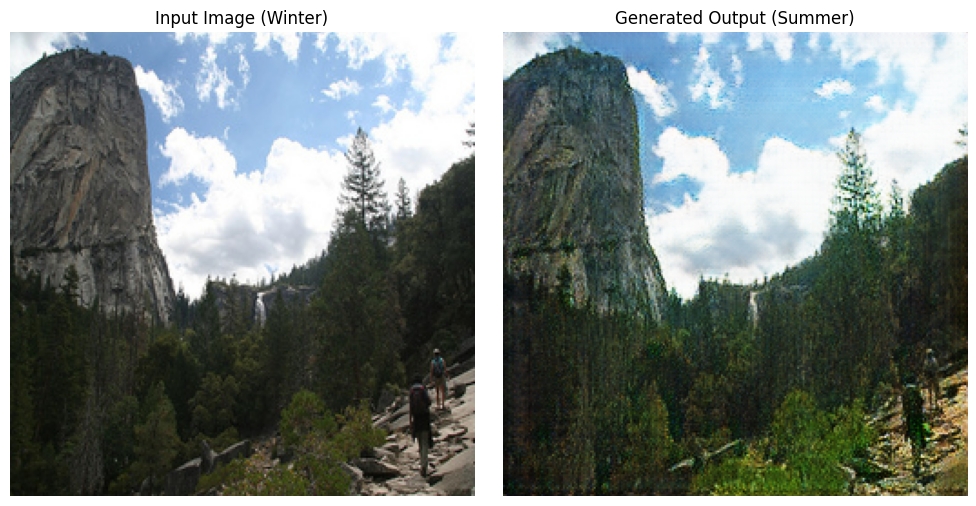

In [16]:
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import torch
import os

# --- 1. SETUP PATHS ---
img_path = r"C:\Users\Misbah Al Mamun\OneDrive\Documents\Dip project\Sum(A)-Win(B) dataset\testA\2010-10-05 19_08_31.jpg"

print(f"Processing image: {img_path}")

# --- 2. CHECK FOR GENERATOR ---
# Verifies that 'generator' exists in memory before proceeding
if 'generator' not in globals():
    print("\nCRITICAL ERROR: 'generator' variable is not defined!")
    print("Please run the cell where you load your model weights first (e.g., netG = ... or generator = ...)")
    raise NameError("'generator' not found in memory.")

# --- 3. PREPARE DATA ---
# Define transforms (Resize to 256x256 and Normalize)
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load and process image
if not os.path.exists(img_path):
    print(f"Error: File not found at path: {img_path}")
else:
    # Open image and convert to RGB
    real_image_pil = Image.open(img_path).convert('RGB')
    # Add batch dimension (1, 3, 256, 256)
    input_tensor = transform(real_image_pil).unsqueeze(0) 

    # Set device to GPU if available
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    input_tensor = input_tensor.to(device)
    
    # Ensure generator is on the same device and in eval mode
    generator.to(device)
    generator.eval() 

    print("Generating image...")
    
    # --- 4. RUN GENERATOR ---
    with torch.no_grad():
        fake_image_tensor = generator(input_tensor)

    # --- 5. DISPLAY HELPER FUNCTION ---
    # Converts tensor back to a displayable image format
    def tensor_to_display(tensor):
        img = tensor.cpu().clone().squeeze(0) # Remove batch dimension
        img = img * 0.5 + 0.5    # Un-normalize (bring to 0-1 range)
        img = img.clamp(0, 1)    # Ensure values are strictly between 0 and 1
        return img.permute(1, 2, 0).numpy() # Convert (C,H,W) to (H,W,C)

    # --- 6. PLOT RESULTS ---
    plt.figure(figsize=(10, 5))

    # Display Input Image
    plt.subplot(1, 2, 1)
    plt.title("Input Image (Winter)")
    plt.imshow(tensor_to_display(input_tensor))
    plt.axis('off')

    # Display Generated Output
    plt.subplot(1, 2, 2)
    plt.title("Generated Output (Summer)")
    plt.imshow(tensor_to_display(fake_image_tensor))
    plt.axis('off')

    plt.tight_layout()
    plt.show()